# 01 探索的データ解析 (EDA)

**目的**:  
La2Ni3 高温高圧水素吸蔵 放射光XRD その場観察した316パターンの時系列XRDデータに対し、データを概要を把握する。  

## 対象読者・前提知識・動作環境・版とライセンス

**対象読者**:
ARIMデータポータル会員の研究者・技術者を想定しています。以下の基礎知識を前提としています:

- Pythonの基礎文法（変数・関数・for文・pandas/numpyの基本操作）
- **scikit-learnの機械学習基礎**: 主成分分析（PCA）、K-means クラスタリング、交差検証（cross-validation）、モデル評価指標（精度・RMSE等）
- **XRDの基本知識**: Braggの法則、d間隔と結晶構造の関係、高温・高圧下での時間分解測定の概念

一方、放射光X線回折(XRD)・高圧実験の詳細な専門知識は前提としません。専門用語は初出時に簡単な説明を添えます。

**シリーズ構成**:   
本ノートブックは「La2Ni3高圧水素化その場観察XRD」4部作の第1部です。

1. `01_eda.ipynb`（本ノートブック）: 探索的データ解析（EDA） — データの全体像を把握する
2. `02_signal_processing.ipynb`: 信号処理（スムージング・ベースライン補正・ピーク検出）
3. `03_machine_learning.ipynb`: 機械学習による相変化の自動検出
4. `04_data_analysis_summary.ipynb`: 01〜03の結果統合と文献との比較考察

**動作環境**:  
Python 3.13、pandas・numpy・matplotlib・seabornで動作確認しています（本ノートブックはscikit-learn・scipyは使用しません）。日本語フォントは`matplotlib_fontja`パッケージを利用します。

**データの出典・ライセンス**:   
出典：　ARIMデータポータルデータセット  
課題番号：　JPMXP1222QS0007  
データセット名：　高圧下での新規La-Ni水素化物の形成過程の観測  
代表者：佐藤豊人 芝浦工業大学  
DOI：　https://doi.org/10.71947/arim.jpmxp1222qs0007  


SPring-8 BL14B1で取得したLa2Ni3合金の高温高圧その場観察エネルギー分散型XRDデータを使用しています。データの再配布・二次利用条件はARIMデータポータルの利用規約に従ってください。

## 教材の目的

このシリーズの教材は、**単なるAIで生成されたコードの学習を目的としていません**。代わりに、以下を重視しています:

1. **基礎知識に基づくコード検証**: 提供されるPythonコードが、XRDデータ処理・機械学習の原理に基づいて**適切に実装されているか**を、自身の基礎知識を使って主体的に確認・検証すること
2. **専門知識の実践活用**: 化学・物理・データ科学の基礎原理と、その実装としてのコードを一体として理解すること
3. **実験データの解釈**: 結果の正当性を根拠立てて判断すること

各ノートブックの各セルには「《○○さんへの質問予定》」というコメント欄があります。これは実際の実験者・データ取得者への確認・質問ポイントです。各ステップが適切であるか、その根拠とともに考察してください。

### 教材への接続
Google Colab環境でこのノートブックを実行する場合は、次のセルを実行してください。（<font color="red">ローカル環境などGoogle Colabを使わない場合は不要です</font>）

In [ ]:
! pip install matplotlib_fontja
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_1_scikit-learn.git
%cd Advanced_Tutorial_1_scikit-learn

## 0. データセットの読み込みと前処理

### ライブラリのインポート
本コードで扱うpythonのライブラリをimport文でロードします。 

In [1]:
import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import matplotlib_fontja

warnings.filterwarnings("ignore")

### 作業フォルダーの設定
プロジェクトルート:  
Jupyterは通常notebookファイルのあるフォルダをカレントディレクトリとして起動するため、Path.cwd()がそのままプロジェクトルートになります。

In [3]:
BASE_DIR = Path.cwd()

DATA_PROC = BASE_DIR / "data" / "processed"
XRD_REF = DATA_PROC / "xrd" / "reference"
XRD_SEQ = DATA_PROC / "xrd" / "sequential"
META_DIR = DATA_PROC / "metadata"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Checking data paths:")

for p in [XRD_REF, XRD_SEQ, META_DIR]:
    print(f"  {p}: {'OK' if p.exists() else 'NOT FOUND'}")

Checking data paths:
  c:\Users\a013662\Dropbox\ARIM\QST-files\data\processed\xrd\reference: OK
  c:\Users\a013662\Dropbox\ARIM\QST-files\data\processed\xrd\sequential: OK
  c:\Users\a013662\Dropbox\ARIM\QST-files\data\processed\metadata: OK


## 1. 測定データの読み込みと概観

《質問：島田様》こちらの"metadata_table.csv"はClaudeでまとめたものです。indexからremarkまで12項目をまとめた一覧ですが、内容について、簡単な解説をお願いします。

In [4]:
# metadata_table.csv 読み込み
meta_path = META_DIR / "metadata_table.csv"

df_meta = pd.read_csv(meta_path)
df_meta

,index,filename,time,temperature_K,pressure_GPa,press_load_ton,measurement_mode,live_time_sec,dead_time_pct,2theta_deg,heating_conditions,remark
0,0,A2308001,2022-07-31 10:26:03,310.61,1.00,10.00,Real,60.00,5.72,6.0,V(V)=5.01 C(A)=0.39 P(W)=1.97 R(OHM)=12.784,NaN
1,1,A2308002,2022-07-31 10:28:57,310.33,1.00,10.00,Real,60.00,10.53,6.0,V(V)=5.02 C(A)=0.38 P(W)=1.91 R(OHM)=13.153,NaN
2,2,A2308003,2022-07-31 16:00:19,300.15,0.00,0.00,Real,71.32,4.96,6.0,V(V)=0.00 C(A)=0.00 P(W)=0.00 R(OHM)=0.000,NaN
3,3,seq_0001,2022-07-31 10:41:12,311.48,1.00,10.00,Separate,54.22,10.53,6.0,V(V)=5.14 C(A)=0.41 P(W)=2.13 R(OHM)=12.396,NaN
4,4,seq_0002,2022-07-31 10:42:13,395.00,1.00,10.00,Separate,53.52,10.53,6.0,V(V)=13.92 C(A)=1.28 P(W)=17.82 R(OHM)=10.870,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
314,314,seq_0312,2022-07-31 15:52:13,300.15,0.28,2.84,Separate,57.13,10.53,6.0,V(V)=0.00 C(A)=0.00 P(W)=0.00 R(OHM)=0.000,NaN
315,315,seq_0313,2022-07-31 15:53:14,300.15,0.21,2.08,Separate,57.25,10.53,6.0,V(V)=0.00 C(A)=0.00 P(W)=0.00 R(OHM)=0.000,NaN
316,316,seq_0314,2022-07-31 15:54:14,300.15,0.13,1.33,Separate,56.94,10.53,6.0,V(V)=0.00 C(A)=0.00 P(W)=0.00 R(OHM)=0.000,NaN
317,317,seq_0315,2022-07-31 15:55:14,300.15,0.06,0.58,Separate,57.33,10.53,6.0,V(V)=0.00 C(A)=0.00 P(W)=0.00 R(OHM)=0.000,NaN


### 参照パターン（index 0-2）と時系列パターン（index 3-318）を分離

《質問：島田様》　こちらの参照パターンと時系列パターンの分離操作は正しいでしょうか。登録データでは必ず参照データを、何かパターンで登録しているのかをおしえてください。

In [5]:
# 参照パターン（index 0-2）と時系列パターン（index 3-318）を分離
df_ref = df_meta[df_meta["filename"].str.startswith("A230")].copy()
df_seq = df_meta[df_meta["filename"].str.startswith("seq")].copy()
df_seq = df_seq.reset_index(drop=True)

print(f"Reference patterns: {len(df_ref)}")
print(f"Sequential (time-series) patterns: {len(df_seq)}")
print(df_seq[["index", "filename", "time", "temperature_K", "pressure_GPa"]].head())

Reference patterns: 3
Sequential (time-series) patterns: 316
   index  filename                 time  temperature_K  pressure_GPa
0      3  seq_0001  2022-07-31 10:41:12         311.48           1.0
1      4  seq_0002  2022-07-31 10:42:13         395.00           1.0
2      5  seq_0003  2022-07-31 10:43:13         473.26           1.0
3      6  seq_0004  2022-07-31 10:44:13         473.10           1.0
4      7  seq_0005  2022-07-31 10:45:13         473.14           1.0


## 2. 温度・圧力の時系列プロファイルの表示

《質問：齋藤様》　「温度」・「圧力」・「デッドタイム」の時系列プロファイルとなります。    
1. 昇温・昇圧のルール（最初の設定温度、昇温速度）は何か定めはありますか？　　
1. ターゲット温度やターゲット圧力は事前にどのように決めるものでしょうか？  　　
1. ターゲット温度よりも約200℃ほど高い温度で測定をしています。これはどのような意味をもちますか？  　　
1. 降温側は一気に温度を下げています。不可逆性の反応などがある場合には、何か見ておくべきことがありますか？  　　
1. 「デッドタイム」とはどのような測定指標でしょうか。　デッドタイムを変更するようなことはありますか？  

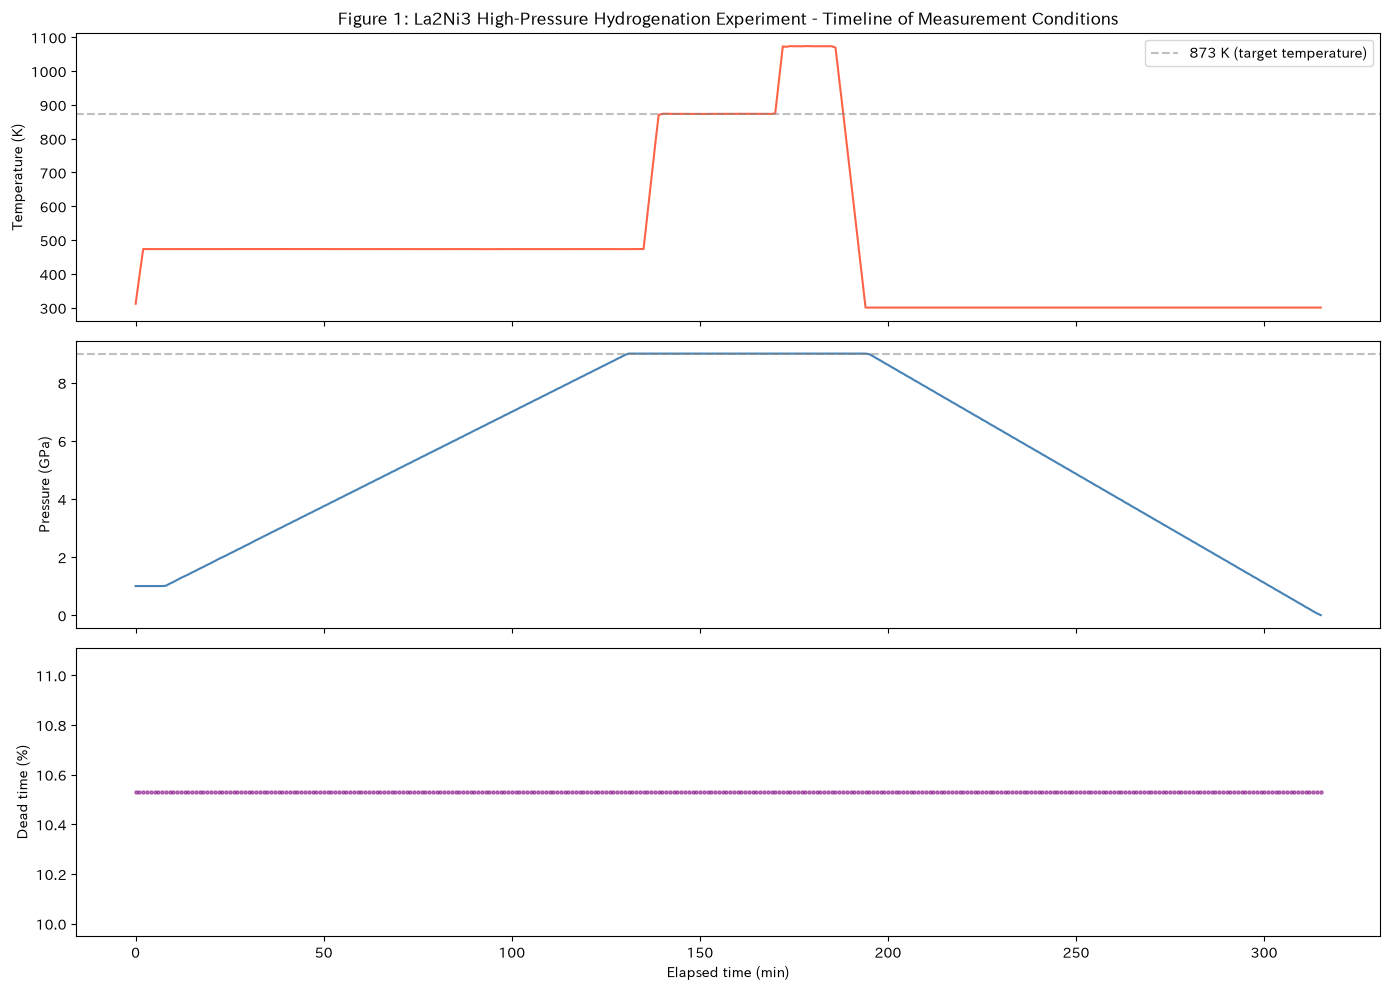

Saved: output/fig01_conditions_timeseries.png


In [6]:
# 時刻列をdatetimeに変換
df_seq["datetime"] = pd.to_datetime(df_seq["time"])
df_seq["elapsed_min"] = (df_seq["datetime"] - df_seq["datetime"].iloc[0]).dt.total_seconds() / 60

# 温度・圧力の時系列プロット
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df_seq["elapsed_min"], df_seq["temperature_K"], color="tomato", lw=1.5)
axes[0].set_ylabel("Temperature (K)")
axes[0].set_title("Figure 1: La2Ni3 High-Pressure Hydrogenation Experiment - Timeline of Measurement Conditions")
axes[0].axhline(873, color="gray", ls="--", alpha=0.5, label="873 K (target temperature)")
axes[0].legend()

axes[1].plot(df_seq["elapsed_min"], df_seq["pressure_GPa"], color="steelblue", lw=1.5)
axes[1].set_ylabel("Pressure (GPa)")
axes[1].axhline(9, color="gray", ls="--", alpha=0.5)

axes[2].scatter(df_seq["elapsed_min"], df_seq["dead_time_pct"], s=5, color="purple", alpha=0.5)
axes[2].set_ylabel("Dead time (%)")
axes[2].set_xlabel("Elapsed time (min)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig01_conditions_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: output/fig01_conditions_timeseries.png")

## 圧力-温度 トラジェクトリプロット　　
《質問：齋藤様》　「温度」・「圧力」のトラジェクトリのような図となります。必要な情報は含まれているでしょうか。

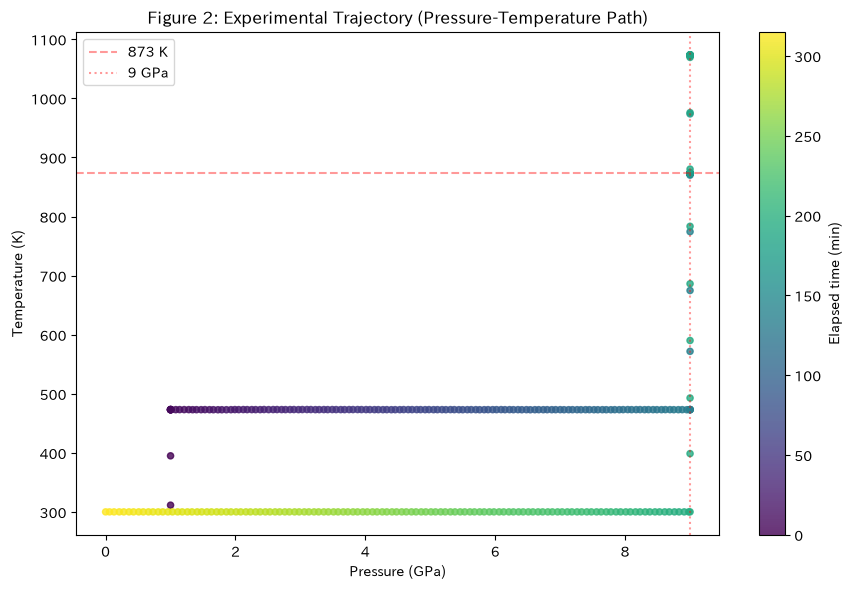

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(df_seq["pressure_GPa"], df_seq["temperature_K"],
                c=df_seq["elapsed_min"], cmap="viridis", s=20, alpha=0.8)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Elapsed time (min)")

ax.set_xlabel("Pressure (GPa)")
ax.set_ylabel("Temperature (K)")
ax.set_title("Figure 2: Experimental Trajectory (Pressure-Temperature Path)")
# 873 K, 9 GPa の目標点
ax.axhline(873, color="red", ls="--", alpha=0.4, label="873 K")
ax.axvline(9, color="red", ls=":", alpha=0.4, label="9 GPa")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig02_PT_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. XRDパターンの読み込みと可視化

《質問：島田様》　入射エネルギーからd間隔への変換する関数はOKでしょうか。

In [12]:
def load_xrd(path):
    """
    XRDパターンのCSVを読み込む(列: ch, energy, intensity)
    """

    return pd.read_csv(path)

def energy_to_d(energy_keV, two_theta_deg=6.0):
    """
    エネルギー分散型XRDにおける、エネルギー(keV)からd間隔(Å)への変換。
    固定角 2θ のエネルギー分散型XRDでは、Braggの法則 nλ = 2d sinθ と
    X線のエネルギー-波長関係 E = hc / λ を組み合わせて
    d = hc / (2 E sinθ) が得られる (hc = 12.398 keV·Å)。
    """

    theta_rad = np.radians(two_theta_deg / 2)
    return 12.398 / (2 * np.sin(theta_rad) * energy_keV)

## 参照パターンの読み込みと可視化　　
《質問：齋藤様》  
３つの参照パターンを横軸を入射エネルギーでの表示と、d間隔へ変換したものでの表示としております。特に問題はございませんでしょうか。　　
また、実験の遂行上、参照パターンにおける確認事項（パターンの見方）があればご教示ください。

In [13]:
# 参照パターンを読み込む
ref_files = sorted([f for f in os.listdir(XRD_REF) if f.endswith(".csv") and f.startswith("A230")])
print("Reference CSV files:", ref_files)

Reference CSV files: ['A2308001.csv', 'A2308002.csv', 'A2308003.csv']


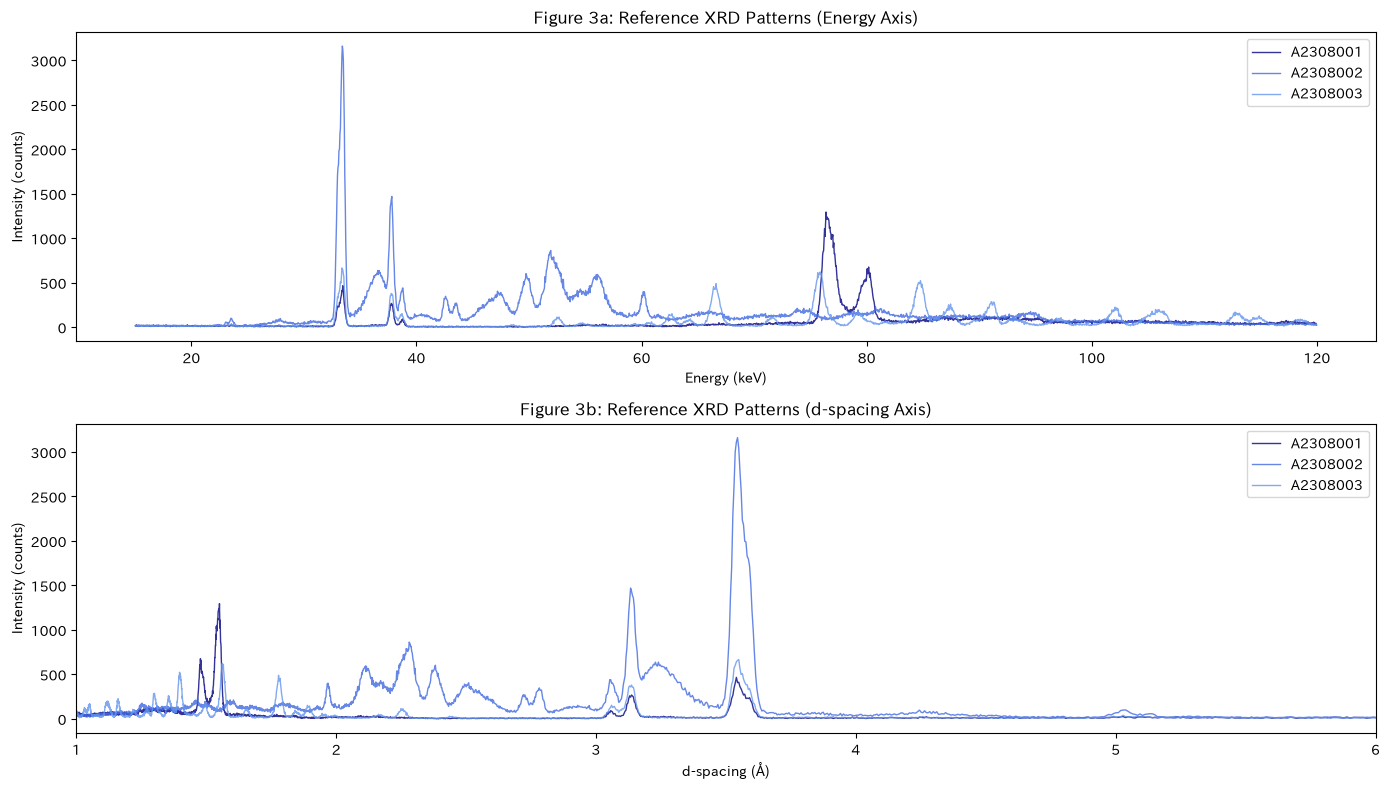

In [14]:
# 参照パターンのプロット（エネルギー軸・d値軸）
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
colors = ["navy", "royalblue", "cornflowerblue"]

for i, fname in enumerate(ref_files):
    df_xrd = load_xrd(XRD_REF / fname)
    label = fname.replace(".csv", "")
    
    # エネルギー軸（低エネルギー側は雑音のためカット）
    mask = (df_xrd["energy"] > 15) & (df_xrd["energy"] < 120)
    axes[0].plot(df_xrd["energy"][mask], df_xrd["intensity"][mask],
                 label=label, alpha=0.8, lw=1, color=colors[i % 3])
    # d値軸
    d_vals = energy_to_d(df_xrd["energy"][mask])
    axes[1].plot(d_vals, df_xrd["intensity"][mask],
                 label=label, alpha=0.8, lw=1, color=colors[i % 3])

axes[0].set_xlabel("Energy (keV)")
axes[0].set_ylabel("Intensity (counts)")
axes[0].set_title("Figure 3a: Reference XRD Patterns (Energy Axis)")
axes[0].legend()

axes[1].set_xlabel("d-spacing (\u00c5)")
axes[1].set_ylabel("Intensity (counts)")
axes[1].set_title("Figure 3b: Reference XRD Patterns (d-spacing Axis)")
axes[1].set_xlim(1, 6)  # 主要ピーク範囲
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig03_reference_xrd.png", dpi=150, bbox_inches="tight")
plt.show()

## 時系列XRDパターンのプロット
《質問：島田様》  
AIではデフォルトとして10本の任意の測定データを時系列プロット（WaterFall型）しています。何か、パターンがある場合にはどのようなルールで作成するものでしょうか。（横型よりも縦型がよい。温度間隔が必要などがあれば教えてください）　　

また、QSTルールでのWaterFallプロットのコードがあれば、ぜひ、教えてください。

Number of sequential CSV files: 316


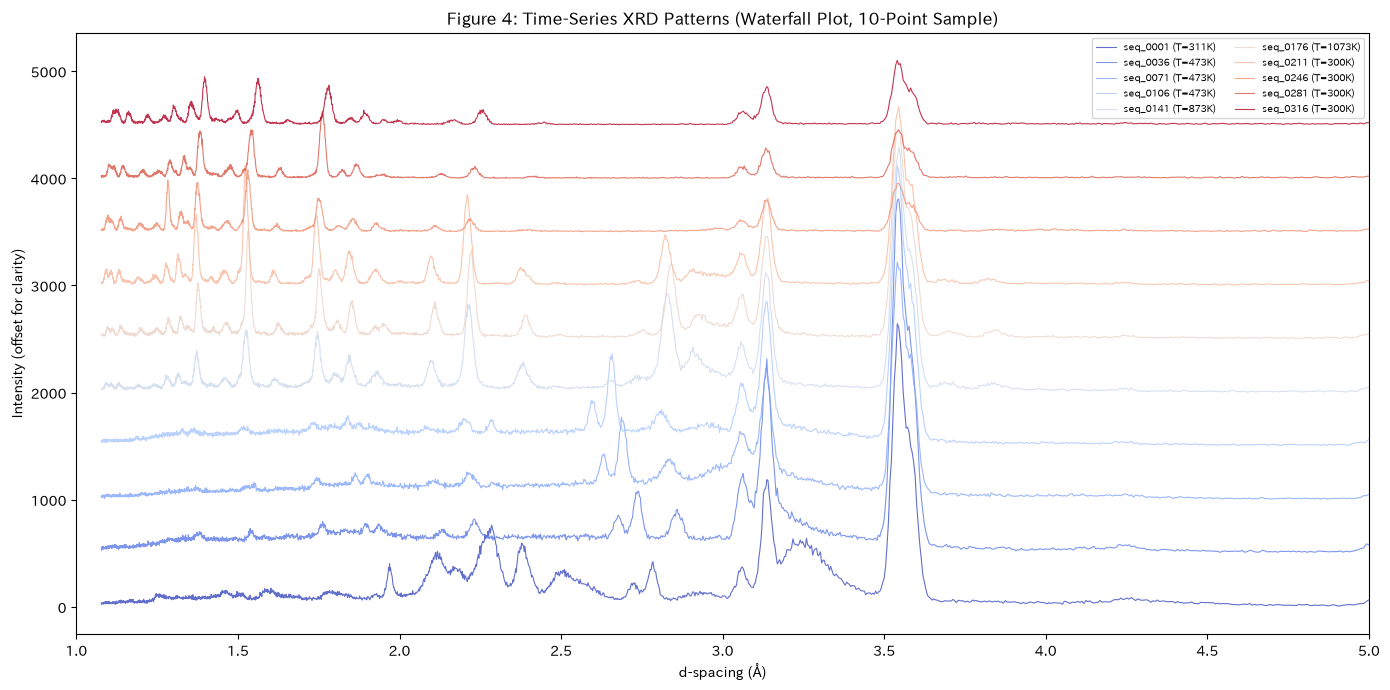

In [15]:
# 時系列XRDパターンのサンプルを抽出してプロット
seq_files = sorted([f for f in os.listdir(XRD_SEQ) if f.endswith(".csv")])
n_seq = len(seq_files)
print(f"Number of sequential CSV files: {n_seq}")

# 等間隔でサンプリング（10件）
sample_idx = np.linspace(0, n_seq - 1, 10, dtype=int)
sample_files = [seq_files[i] for i in sample_idx]

fig, ax = plt.subplots(figsize=(14, 7))
cmap = plt.cm.coolwarm

for j, fname in enumerate(sample_files):
    df_xrd = load_xrd(XRD_SEQ / fname)
    mask = (df_xrd["energy"] > 20) & (df_xrd["energy"] < 110)
    d_vals = energy_to_d(df_xrd["energy"][mask])
    idx_num = int(fname.replace("seq_", "").replace(".csv", ""))

    # metadata_table.csv の index 0-2 は参照パターン(A2308001-003)、
    # index 3以降が seq_0001, seq_0002, ... に対応する（+2のオフセット）
    
    temp_row = df_seq.loc[df_seq["index"] == idx_num + 2, "temperature_K"]
    temp_label = f"{temp_row.values[0]:.0f}K" if len(temp_row) else "N/A"
    color = cmap(j / 9)
    ax.plot(d_vals, df_xrd["intensity"][mask] + j * 500,
            alpha=0.8, lw=0.8, color=color,
            label=f"{fname.replace('.csv','')} (T={temp_label})")

ax.set_xlabel("d-spacing (\u00c5)")
ax.set_ylabel("Intensity (offset for clarity)")
ax.set_title("Figure 4: Time-Series XRD Patterns (Waterfall Plot, 10-Point Sample)")
ax.set_xlim(1.0, 5.0)
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig04_xrd_waterfall_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 基本統計量　　

《質問：齋藤様》  
機械学習をかけるにあたり、事前に可視化をして確認をするステップとしてEDAがあります。測定条件に関する基本統計量で確認すべき点があればご指摘ください。

また、コックピットパネルではありませんが、計測条件を把握するためにあったらいいと思われる表示・可視化図があればご指摘ください。

In [15]:
print("=== Summary statistics of measurement conditions ===")
print(df_seq[["temperature_K","pressure_GPa","live_time_sec","dead_time_pct"]].describe().round(2))
print()
print("=== Distribution of temperature stages ===")

temp_bins = [0, 400, 600, 800, 1000, 1200]

df_seq["temp_stage"] = pd.cut(df_seq["temperature_K"], bins=temp_bins,
                               labels=["<400K", "400-600K", "600-800K", "800-1000K", ">1000K"])
print(df_seq["temp_stage"].value_counts().sort_index())

=== Summary statistics of measurement conditions ===
       temperature_K  pressure_GPa  live_time_sec  dead_time_pct
count         316.00        316.00         316.00         316.00
mean          482.77          5.50          55.95          10.53
std           219.20          2.87           1.20           0.00
min           300.15          0.00          53.31          10.53
25%           300.15          2.98          54.78          10.53
50%           473.10          5.73          56.14          10.53
75%           473.24          8.47          56.99          10.53
max          1073.58          9.00          57.86          10.53

=== Distribution of temperature stages ===
temp_stage
<400K        125
400-600K     137
600-800K       4
800-1000K     35
>1000K        15
Name: count, dtype: int64


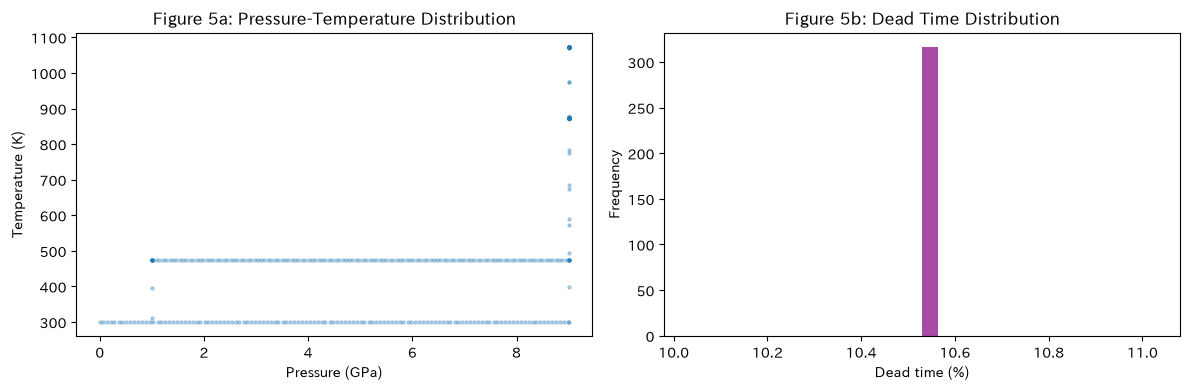

Unique dead_time_pct values in sequential patterns: [10.53]
EDA notebook complete


In [16]:
# 圧力・温度の相関、デッドタイムの分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df_seq["pressure_GPa"], df_seq["temperature_K"], s=5, alpha=0.3)
axes[0].set_xlabel("Pressure (GPa)"); axes[0].set_ylabel("Temperature (K)")
axes[0].set_title("Figure 5a: Pressure-Temperature Distribution")

axes[1].hist(df_seq["dead_time_pct"], bins=30, color="purple", alpha=0.7)
axes[1].set_xlabel("Dead time (%)"); axes[1].set_ylabel("Frequency")
axes[1].set_title("Figure 5b: Dead Time Distribution")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig05_eda_stats.png", dpi=150, bbox_inches="tight")
plt.show()

# 補足: 上のdescribe()でdead_time_pctの標準偏差が0.00であることに注目すると分かる通り、
# 時系列パターン316件はすべて同一のデッドタイム(10.53%)で記録されている
# （検出器の設定が自動スキャン中は固定されていたと考えられる）。
# そのため図5bのヒストグラムは単一のビンに集中する。
print("Unique dead_time_pct values in sequential patterns:", df_seq["dead_time_pct"].unique())
print("EDA notebook complete")

## 5. まとめ・今後の課題・演習問題

本ノートブックは探索的データ解析（EDA）のみを目的としており、複数モデルの学習・比較は行っていないため、比較表・比較図はここには置いていません（モデルの比較は`03_machine_learning.ipynb`で扱います）。

### まとめ

- La2Ni3合金の高温高圧水素化その場観察実験（SPring-8 BL14B1、課題番号22QS0007）のデータは、参照パターン3件（A2308001〜003）と時系列パターン316件（seq_0001〜0316）の合計319件で構成されている。時系列パターンは約315分（約5.25時間）にわたり、約60秒間隔で連続測定されたもの。
- 測定条件は温度300.1〜1073.6 K、圧力0〜9 GPaの範囲を推移している。図1・図2から、実験は昇圧・昇温・保持・冷却を複数回繰り返す手順で進行したことが読み取れる。
- デッドタイム(%)は時系列パターン316件すべてで10.53%と完全に一定だった一方、参照パターン3件は4.96〜10.53%とばらついていた（`describe()`の標準偏差が0.00である点から気づける）。自動スキャン中は検出器のデッドタイム関連の設定が固定されていたことが示唆される。
- 図3・図4のXRDパターンから、d=2〜3 Å付近に複数のブロードなピークがあり、時系列とともに強度・位置が変化している様子が視覚的に確認できる。詳細な定量解析（スムージング・ピーク検出）は`02_signal_processing.ipynb`で行う。

### 本ノートブックで扱っていないこと（今後の課題）

- ノイズ除去・ベースライン補正・ピーク検出などの定量的な信号処理（→`02_signal_processing.ipynb`）
- 機械学習によるフェーズ（相）の自動分類（→`03_machine_learning.ipynb`）
- 文献値（Sato et al. 2023, 2025）との定量的な比較（→`04_data_analysis_summary.ipynb`）
- 結晶構造の指数付け（PDindexer等によるhkl帰属）やRietveld精密化（本シリーズの範囲外）

### 演習問題

1. `df_seq["temperature_K"]`の値を用いて、温度が873 K（目標温度）を初めて超えるのは何番目の測定（seq番号）か求めてください。
2. 図2（P-T軌跡）のカラーバーは経過時間を表しています。昇温・降温が何サイクル繰り返されているか、図を目視で数えてください。
3. `energy_to_d()`関数を使い、任意のエネルギー値（例: 50 keV）に対応するd値を計算し、`two_theta_deg`を6.0°から別の値（例: 8.0°）に変えるとd値がどう変化するか確認してください。
4. `df_ref`（参照パターン3件）の`temperature_K`・`pressure_GPa`を見比べ、それぞれどのような実験条件（初期状態・大気圧参照など）に対応するかを、`data/processed/reference_summary.md`の記載と突き合わせて考察してください。